# Finding the k in k-anonymity
All the other suppresion methods rely on a specific k. This notebook is all about finding the specific k we wanna use for each dataset

In [1]:
from anjana.anonymity import (
    k_anonymity,
    k_anonymity_inner,
)
import masking_effects_on_xai_techniques.hierarchies as hi
import masking_effects_on_xai_techniques.anonymized_preprocessor as anon_prep
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

In [2]:
path = "../data/usa_house/"
data = pd.read_csv(path + "data.csv")
len_data = len(data)

# Clean the data
data.dropna(inplace=True)
data = data.drop("Address", axis=1)

len_clean_data = len(data)
print(f"Dropped {len_data - len_clean_data} rows")
data.to_csv(path + "clean.csv", index=False)

Dropped 0 rows


In [3]:
categories = data.columns.to_list()

hierarchies = dict()
h1 = dict()
h2 = dict()
for cat in categories:
    h1[cat] = dict(pd.read_csv(f"../hierarchies/usa_house/{cat}.csv", header=None))
    h2[cat] = hi.generate_qcut_hierarchy(data[cat], 3)

hierarchies = h1

In [4]:
# Check with mina what should be identified as quai identifiers
quasi_ident = list(data.columns)
quasi_ident.remove("Price")

ident = []
sens_att = "Price"

In [5]:
load_from_files = True
k_list = [2**n for n in range(1, 9)]
supp_level = 20
anon_data = []
if load_from_files:
    target_dir = Path("../data/usa_house/k_anonymity").resolve()
    files = [f for f in target_dir.glob("*") if f.is_file()]
    files = sorted(files, key=lambda p: int(p.name.rstrip(".csv")))
    files
    for file in files:
        anon_data.append(pd.read_csv(file).iloc[:, 1:])  # ignore index col
else:
    for k in k_list:
        print(f"Anonymizing for k={k}")
        anon_df = k_anonymity_inner(
            data, ident, quasi_ident, k, supp_level, hierarchies
        )[0]
        try:
            anon_df = anon_df.drop("index", axis=1)
        except KeyError:
            print("No index column found")
            pass
        anon_data.append(anon_df)
    print("Done anonymizing")

In [6]:
# Normalize the Price
for df in anon_data:
    y = df["Price"]
    scaler = StandardScaler()
    y = scaler.fit_transform(y.values.reshape(-1, 1))
    y = pd.Series(y.flatten())
    df["Price"] = y

In [7]:
scores = []
for df in anon_data:
    df = anon_prep.encode(
        df, hierarchy_path="../hierarchies/usa_house/", skip=["Price"]
    )
    y = df["Price"]
    X = df.drop(columns=["Price"])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=0
    )
    clf = MLPRegressor(
        solver="sgd", alpha=1e-5, hidden_layer_sizes=(10), random_state=1
    )
    clf.fit(X_train, y_train)
    score = clf.score(X_test, y_test)
    scores.append(score)
    print(score)

/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.7530559873690335
0.6505083029360846
0.49714921764461006
0.45729073426008593
0.38513303540505883
0.32081250927626515


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


0.20557571320438006
0.126304811509936


/home/kochc/projects/bachelor/Masking-Effects-on-XAI-Techniques/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


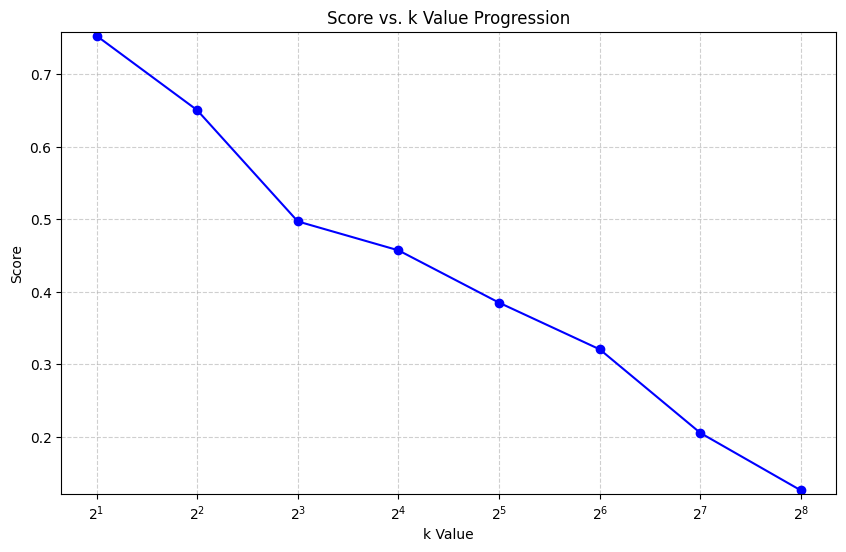

In [9]:
df = pd.DataFrame({"k_value": k_list, "Score": scores})


plt.figure(figsize=(10, 6))


plt.plot(df["k_value"], df["Score"], marker="o", linestyle="-", color="blue")

plt.xscale("log", base=2)

plt.xlabel("k Value")
plt.ylabel("Score")
plt.title("Score vs. k Value Progression")


plt.grid(True, linestyle="--", alpha=0.6)


plt.xticks(k_list)


min_score = min(scores) - 0.005
max_score = max(scores) + 0.005
plt.ylim(min_score, max_score)
plt.show()

Utility is affected a LOT. After a k of $16$ it becomes practically shite. This also makes sense since the data is constantly generalized more and more losing it's granularity. What Mina said abuot the accuracy flatteing after some point is obviously wrong. However, it is important to note that the x-axis is logarithmic, which makes the relationship look linear. For values around $k=2^4$ k has a minimal influence. So we set $k=2^4=16$